<h2>Lab Assignment - 3<br>Scikit-learn: Data Preprocessing and Model Performance Evaluation</h2>

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

### Part A - Data Loading and Preprocessing with Scikit-learn
#### Task 1 - Load and Understand the Dataset

In [2]:
df= pd.read_csv("hotel_bookings.csv")

In [3]:
print("First 5 rows:")
df.head()

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
print("Shape of the data Matrix")
df.shape

Shape of the data Matrix


(119390, 32)

In [5]:
print("stats of the null count ant data type")
df.info()

stats of the null count ant data type
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  in

In [6]:
print("Descriptive Statistics")
df.describe()

Descriptive Statistics


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
print("the data types of the attributes")
df.dtypes

the data types of the attributes


hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [8]:
print("\nClass Distribution of is_canceled:")
df["is_canceled"].value_counts()


Class Distribution of is_canceled:


is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [9]:
print("\nClass Distribution of is_canceled:")
print(df["is_canceled"].value_counts())

print("\nClass Distribution (%):")
print(df["is_canceled"].value_counts(normalize=True) * 100)

# 8. Set target variable
y = df["is_canceled"]


X = df.drop(columns=["is_canceled"])

# 10. Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumber of numerical features:", len(numerical_cols))
print("Number of categorical features:", len(categorical_cols))


Class Distribution of is_canceled:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Class Distribution (%):
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

Number of numerical features: 19
Number of categorical features: 12


<h3>Task 2</h3>

<h3>Missing- values and Percentages</h3>

In [10]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

missing_summary

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [11]:
high_missing = missing_summary[
    missing_summary["Missing Percentage"] > 50
]

high_missing

,Missing Count,Missing Percentage
company,112593,94.306893


### Droping the company column

In [12]:
df = df.drop(columns=["company"])

In [13]:
y = df["is_canceled"]
y

0         0
1         0
2         0
3         0
4         0
         ..
119385    0
119386    0
119387    0
119388    0
119389    0
Name: is_canceled, Length: 119390, dtype: int64

In [14]:
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

df = df.drop(columns=leakage_columns)

In [15]:
y = df["is_canceled"]

X = df.drop(columns=["is_canceled"])

X.shape, y.shape

((119390, 28), (119390,))

### Nuemrical features for outliers

In [16]:
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_cols

['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [17]:
selected_numerical = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

X[selected_numerical].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0
previous_bookings_not_canceled,119390.0,0.137097,1.497437,0.00,0.00,0.000,0.0,72.0
booking_changes,119390.0,0.221124,0.652306,0.00,0.00,0.000,0.0,21.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0


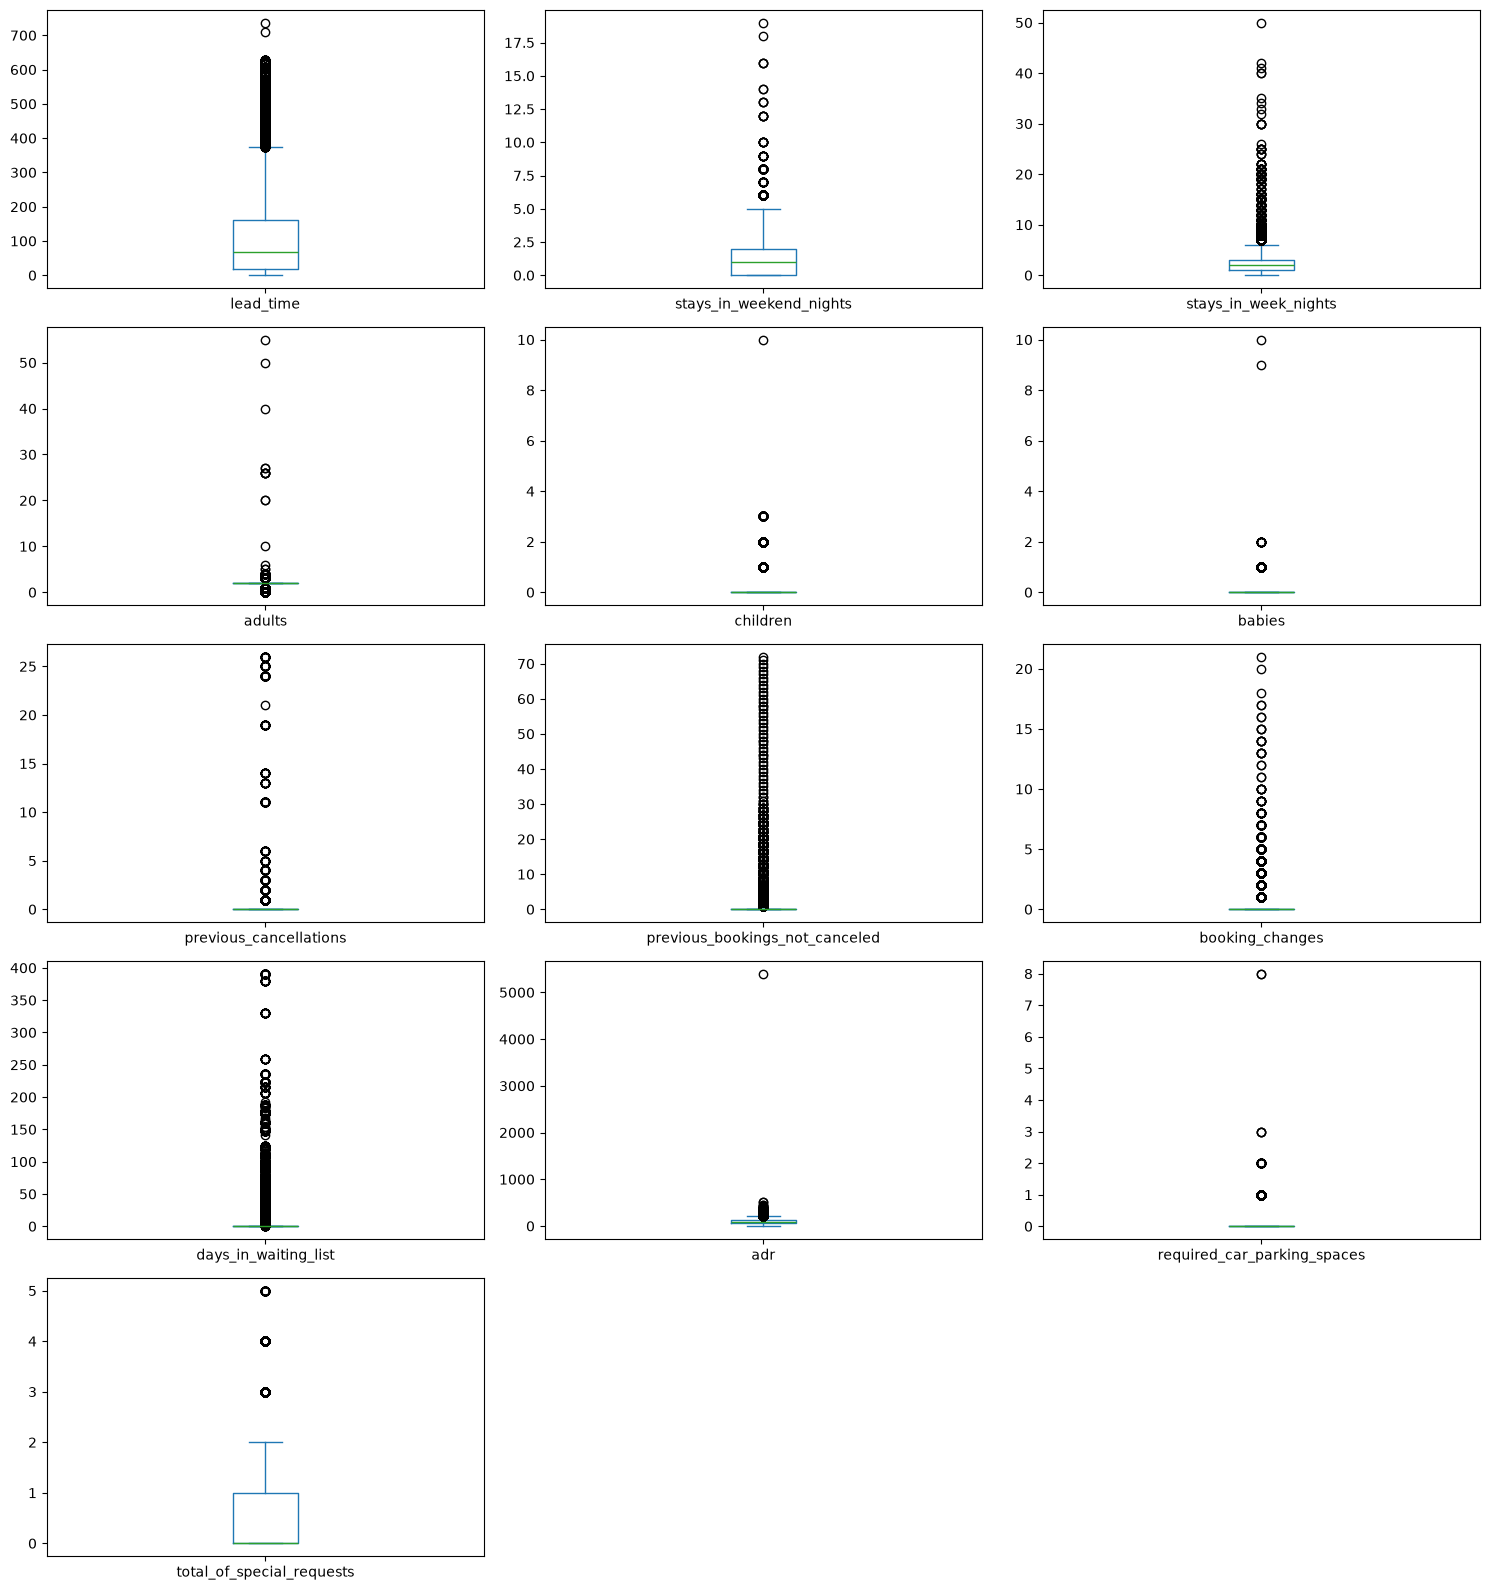

In [18]:

X[selected_numerical].plot(
    kind="box",
    subplots=True,
    layout=(5, 3),
    figsize=(15, 16),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

In [19]:
outlier_summary = []

for col in selected_numerical:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (X[col] < lower_bound) | (X[col] > upper_bound)

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": mask.sum(),
        "Outlier Percentage": mask.mean() * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
3,adults,2.000,2.000,29710,24.884831
8,booking_changes,0.000,0.000,18076,15.140297
4,children,0.000,0.000,8590,7.194907
11,required_car_parking_spaces,0.000,0.000,7416,6.211576
6,previous_cancellations,0.000,0.000,6484,5.430941
10,adr,-15.775,211.065,3793,3.176983
9,days_in_waiting_list,0.000,0.000,3698,3.097412
7,previous_bookings_not_canceled,0.000,0.000,3620,3.032080
2,stays_in_week_nights,-2.000,6.000,3354,2.809281
0,lead_time,-195.000,373.000,3005,2.516961


In [20]:
rows_before = len(df)

extreme_adr_mask = df["adr"] > 5000

df = df.loc[~extreme_adr_mask].copy()

rows_removed = rows_before - len(df)

pd.DataFrame({
    "Rows Before": [rows_before],
    "Rows Removed": [rows_removed],
    "Rows After": [len(df)]
})

,Rows Before,Rows Removed,Rows After
0,119390,1,119389


In [21]:
y = df["is_canceled"]

X = df.drop(columns=["is_canceled"])

X.shape, y.shape

((119389, 28), (119389,))

In [22]:
[col for col in ["reservation_status", "reservation_status_date"] 
 if col in X.columns]

[]

# Task 3

### Creating Two Pre Processing Pipelines

In [23]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# Test Train split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [25]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (95511, 28)
X_test : (23878, 28)
y_train: (95511,)
y_test : (23878,)


In [26]:
numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()
print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


### Creating Pipelines

In [27]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [28]:
numerical_pipeline_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [29]:
preprocessor_A = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_A, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)

In [30]:
pipeline_A = Pipeline(steps=[
    ('preprocessor', preprocessor_A)
])

In [33]:
X_train_A = pipeline_A.fit_transform(X_train)

In [34]:
print("Pipeline A")
print("--------------------")
print("Training shape:", X_train_A.shape)

Pipeline A
--------------------
Training shape: (95511, 250)


In [35]:
numerical_pipeline_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

In [36]:
preprocessor_B = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_B, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)

In [37]:
pipeline_B = Pipeline(steps=[
    ('preprocessor', preprocessor_B)
])

In [38]:
X_train_B = pipeline_B.fit_transform(X_train)
X_test_B = pipeline_B.transform(X_test)

In [39]:
print("Pipeline B")
print("--------------------")
print("Training shape:", X_train_B.shape)
print("Testing shape :", X_test_B.shape)

Pipeline B
--------------------
Training shape: (95511, 250)
Testing shape : (23878, 250)


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [41]:
logistic_A = LogisticRegression(max_iter=1000)

logistic_B = LogisticRegression(max_iter=1000)

tree_A = DecisionTreeClassifier(random_state=42)

tree_B = DecisionTreeClassifier(random_state=42)

In [42]:
logistic_pipeline_A = Pipeline(steps=[
    ('preprocessing', pipeline_A),
    ('model', LogisticRegression(max_iter=1000))
])

In [43]:
logistic_pipeline_B = Pipeline(steps=[
    ('preprocessing', pipeline_B),
    ('model', LogisticRegression(max_iter=1000))
])

In [44]:
tree_pipeline_A = Pipeline(steps=[
    ('preprocessing', pipeline_A),
    ('model', DecisionTreeClassifier(random_state=42))
])

In [45]:
tree_pipeline_B = Pipeline(steps=[
    ('preprocessing', pipeline_B),
    ('model', DecisionTreeClassifier(random_state=42))
])

In [46]:
logistic_pipeline_A.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipel

In [47]:
logistic_pipeline_B.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipel

In [48]:
tree_pipeline_A.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipel

In [49]:
tree_pipeline_B.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipel

In [50]:
print("Logistic Regression + Pipeline A:", logistic_pipeline_A)
print("\nLogistic Regression + Pipeline B:", logistic_pipeline_B)
print("\nDecision Tree + Pipeline A:", tree_pipeline_A)
print("\nDecision Tree + Pipeline B:", tree_pipeline_B)

Logistic Regression + Pipeline A: Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('preprocessor',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    KNNImputer()),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['lead_time',
                                                                    'arrival_date_year',
                                                                    'arrival_date_week_number',
                                                                    'arrival_date_day_of_month',
                                                    

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [52]:
models = {
    "Logistic Regression + StandardScaler": logistic_pipeline_A,
    "Logistic Regression + MinMaxScaler": logistic_pipeline_B,
    "Decision Tree + StandardScaler": tree_pipeline_A,
    "Decision Tree + MinMaxScaler": tree_pipeline_B
}

In [53]:
results = []

for name, model in models.items():
    
    # Predictions on training data
    y_train_pred = model.predict(X_train)
    
    # Predictions on testing data
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    # Difference between training and testing accuracy
    accuracy_difference = train_accuracy - test_accuracy
    
    results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train-Test Difference": accuracy_difference
    })

In [54]:
results_df = pd.DataFrame(results)

results_df

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
0,Logistic Regression + StandardScaler,0.818848,0.818033,0.811117,0.663200,0.729738,0.000815
1,Logistic Regression + MinMaxScaler,0.815330,0.813678,0.806555,0.653816,0.722198,0.001652
2,Decision Tree + StandardScaler,0.996356,0.859033,0.805850,0.816054,0.810920,0.137323
3,Decision Tree + MinMaxScaler,0.996356,0.858573,0.804930,0.815941,0.810398,0.137784


In [55]:
results_df = results_df.round(4)

results_df

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
0,Logistic Regression + StandardScaler,0.8188,0.8180,0.8111,0.6632,0.7297,0.0008
1,Logistic Regression + MinMaxScaler,0.8153,0.8137,0.8066,0.6538,0.7222,0.0017
2,Decision Tree + StandardScaler,0.9964,0.8590,0.8059,0.8161,0.8109,0.1373
3,Decision Tree + MinMaxScaler,0.9964,0.8586,0.8049,0.8159,0.8104,0.1378


In [56]:
results_df.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
2,Decision Tree + StandardScaler,0.9964,0.8590,0.8059,0.8161,0.8109,0.1373
3,Decision Tree + MinMaxScaler,0.9964,0.8586,0.8049,0.8159,0.8104,0.1378
0,Logistic Regression + StandardScaler,0.8188,0.8180,0.8111,0.6632,0.7297,0.0008
1,Logistic Regression + MinMaxScaler,0.8153,0.8137,0.8066,0.6538,0.7222,0.0017


In [57]:
logistic_results = results_df[
    results_df["Model"].str.startswith("Logistic Regression")
]

best_logistic_name = logistic_results.loc[
    logistic_results["F1-Score"].idxmax(),
    "Model"
]

print("Best Logistic Regression:", best_logistic_name)

Best Logistic Regression: Logistic Regression + StandardScaler


In [59]:
best_logistic_model = models[best_logistic_name]

In [60]:
y_pred_logistic = best_logistic_model.predict(X_test)

In [61]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm_logistic)

[[13667  1366]
 [ 2979  5866]]


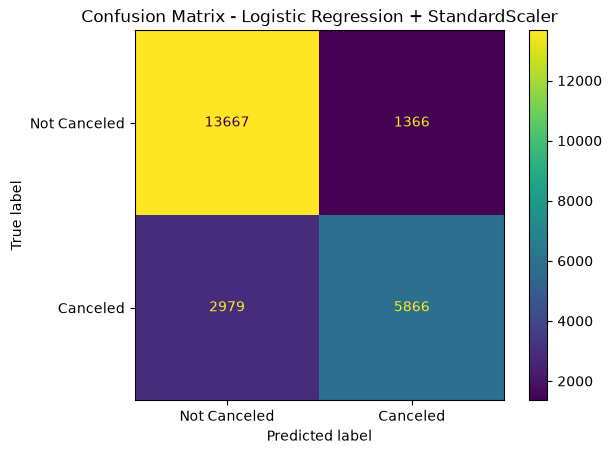

In [62]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()

plt.title(f"Confusion Matrix - {best_logistic_name}")
plt.show()

In [63]:
tree_results = results_df[
    results_df["Model"].str.startswith("Decision Tree")
]

best_tree_name = tree_results.loc[
    tree_results["F1-Score"].idxmax(),
    "Model"
]

print("Best Decision Tree:", best_tree_name)

Best Decision Tree: Decision Tree + StandardScaler


In [64]:
best_tree_model = models[best_tree_name]

In [65]:
y_pred_tree = best_tree_model.predict(X_test)

In [66]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print(cm_tree)

[[13294  1739]
 [ 1627  7218]]


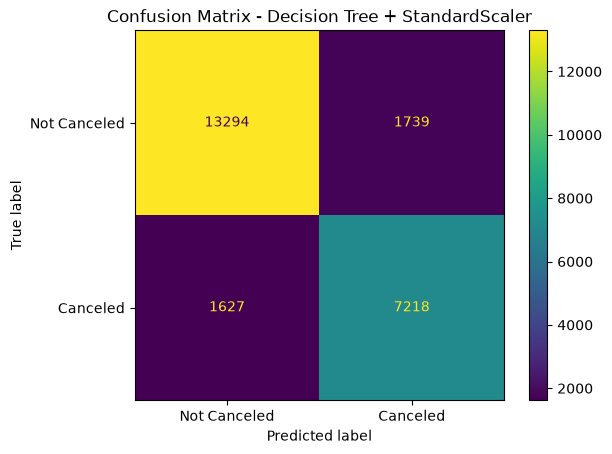

In [67]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()

plt.title(f"Confusion Matrix - {best_tree_name}")
plt.show()

In [68]:
results_df[
    ["Model", "Training Accuracy", "Testing Accuracy", "Train-Test Difference"]
]

,Model,Training Accuracy,Testing Accuracy,Train-Test Difference
0,Logistic Regression + StandardScaler,0.8188,0.8180,0.0008
1,Logistic Regression + MinMaxScaler,0.8153,0.8137,0.0017
2,Decision Tree + StandardScaler,0.9964,0.8590,0.1373
3,Decision Tree + MinMaxScaler,0.9964,0.8586,0.1378


In [69]:
for _, row in results_df.iterrows():
    
    difference = row["Train-Test Difference"]
    
    if difference < 0.03:
        comment = "Small train-test gap; little evidence of overfitting."
    
    elif difference < 0.07:
        comment = "Moderate train-test gap; some overfitting may be present."
    
    else:
        comment = "Large train-test gap; possible overfitting."
    
    print(f"{row['Model']}: {comment}")

Logistic Regression + StandardScaler: Small train-test gap; little evidence of overfitting.
Logistic Regression + MinMaxScaler: Small train-test gap; little evidence of overfitting.
Decision Tree + StandardScaler: Large train-test gap; possible overfitting.
Decision Tree + MinMaxScaler: Large train-test gap; possible overfitting.


#The Decision Tree shows a relatively large difference between training and testing accuracy, indicating possible overfitting.
 This suggests that the tree fits the training data very closely but does not generalize equally well to unseen data. Logistic Regression has a smaller train-test gap and therefore appears to generalize more consistently.

Which preprocessing-model combination gives the best overall result?

he best overall preprocessing-model combination is Decision Tree  with  StandardScaler, as it achieves the highest F1-score on the test set. It also provides a strong testing accuracy, precision, and recall compared with the other combinations.

Does StandardScaler or MinMaxScaler affect Logistic Regression more?

StandardScaler and MinMaxScaler produced very similar Logistic Regression performance, indicating that the choice of scaling method had only a minor effect in this experiment.

Does scaling make a major difference for the Decision Tree? Comment briefly.

Scaling had little effect on the Decision Tree performance. The StandardScaler and MinMaxScaler versions produced similar testing metrics, which is expected because Decision Trees are not sensitive to the scale of numerical features.